[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Lab_Notebooks/chapter_00_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 0 — Precourse Refresher
## Lab: the undergraduate toolkit, in Python

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser, HSBI
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

**Goal of this lab.** Work through every idea of the Chapter 0 slide deck in code: describing one variable and two, probability and Bayes, the standard distributions, standard errors and confidence intervals, hypothesis tests and power, simple linear regression, matrix algebra and gradient descent — finishing with the deck's `[Python]` exercises, fully worked.

**How to use it.** Run the cells in order. Every figure of the deck is rebuilt here from the same data, so you can change a number and watch the picture move. Nothing below assumes more than an introductory undergraduate course.

**Companion slides:** `Lecture_Slides/chapter_00/chapter_00.pdf`.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.

> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import warnings; warnings.filterwarnings('ignore')  # keep output clean; remove to see all warnings
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

ISLP not installed; using CSV / URL fallbacks.


In [2]:
# Chapter 0 also uses scipy.stats (distributions and tests) and statsmodels.
from scipy import stats
import statsmodels.formula.api as smf

ACCENT, ORANGE, GREY = '#26468C', '#C8641E', '#7A7A7A'   # the deck's colours
print('ready')

ready


## 1. Data, variables and notation

A data set is $n$ rows (observations) by $p$ columns (variables). The **type** of the response names the problem: quantitative $\Rightarrow$ regression, qualitative $\Rightarrow$ classification.

In [3]:
Wage = load('Wage')
print('n =', Wage.shape[0], ' p =', Wage.shape[1])
Wage.head()

n = 3000  p = 11


,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [4]:
# What IS each column? dtype is a first hint, but always look at the values.
Wage.dtypes

year            int64
age             int64
maritl         object
race           object
education      object
region         object
jobclass       object
health         object
health_ins     object
logwage       float64
wage          float64
dtype: object

In [5]:
# Quantitative -> mean/SD/quantiles;  qualitative -> counts and proportions.
display(Wage[['age', 'wage']].describe().T)
display(Wage['education'].value_counts())
display(Wage['education'].value_counts(normalize=True).round(3))

,count,mean,std,min,25%,50%,75%,max
age,3000.0,42.414667,11.542406,18.000000,33.75000,42.000000,51.000000,80.00000
wage,3000.0,111.703608,41.728595,20.085537,85.38394,104.921507,128.680488,318.34243


education
2. HS Grad            971
4. College Grad       685
3. Some College       650
5. Advanced Degree    426
1. < HS Grad          268
Name: count, dtype: int64

education
2. HS Grad            0.324
4. College Grad       0.228
3. Some College       0.217
5. Advanced Degree    0.142
1. < HS Grad          0.089
Name: proportion, dtype: float64

> **Watch out.** `Wage` carries both `wage` and `logwage`. The second is a transform *of the response itself*: using it as a predictor would leak the answer into the model. Always check what the columns actually are.

## 2. Describing one variable: centre, spread, shape

Three questions, always in this order: where do typical values sit, how much do they differ, and what shape is the distribution?

In [6]:
x = np.array([2, 4, 4, 5, 7, 8, 12])           # the deck's worked example

print('mean   ', x.mean())                     # 6.0
print('median ', np.median(x))                 # 5.0
print('mode   ', stats.mode(x, keepdims=False).mode)   # 4
print('var  (n-1)', x.var(ddof=1))             # 11.0  <- the SAMPLE variance
print('sd   (n-1)', x.std(ddof=1).round(3))    # 3.317
print('var  (n)  ', x.var().round(3), ' <- numpy default: NOT what you want')

mean    6.0
median  5.0
mode    4
var  (n-1) 11.0
sd   (n-1) 3.317
var  (n)   9.429  <- numpy default: NOT what you want


**The `ddof` trap.** `numpy` divides by $n$ by default; `pandas` divides by $n-1$. The sample variance divides by $n-1$ because one degree of freedom was spent estimating $\bar x$. Always pass `ddof=1` in numpy — or use pandas and know why it differs.

In [7]:
q1, med, q3 = np.percentile(x, [25, 50, 75])
iqr = q3 - q1
print(f'Q1={q1}  median={med}  Q3={q3}  IQR={iqr}')
print(f'fences: [{q1 - 1.5*iqr}, {q3 + 1.5*iqr}]  -> outliers:', x[(x < q1-1.5*iqr) | (x > q3+1.5*iqr)])

Q1=4.0  median=5.0  Q3=7.5  IQR=3.5
fences: [-1.25, 12.75]  -> outliers: []


count    3000.00
mean      111.70
std        41.73
min        20.09
25%        85.38
50%       104.92
75%       128.68
max       318.34


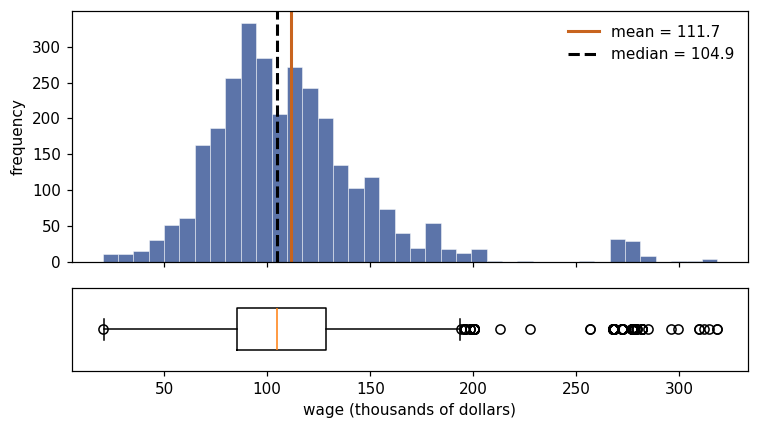

In [8]:
# The same summary on real data, and the five-number summary as a boxplot.
w = Wage['wage']
print(w.describe().round(2).to_string())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.hist(w, bins=40, color=ACCENT, alpha=.75, edgecolor='white', lw=.4)
ax1.axvline(w.mean(), color=ORANGE, lw=2, label=f'mean = {w.mean():.1f}')
ax1.axvline(w.median(), color='black', lw=2, ls='--', label=f'median = {w.median():.1f}')
ax1.legend(frameon=False); ax1.set_ylabel('frequency')
ax2.boxplot(w, vert=False, widths=.5)
ax2.set_yticks([]); ax2.set_xlabel('wage (thousands of dollars)')
plt.tight_layout(); plt.show()

Mean $>$ median, and a long upper tail: **right-skewed**. For skewed variables report the median and IQR alongside the mean.

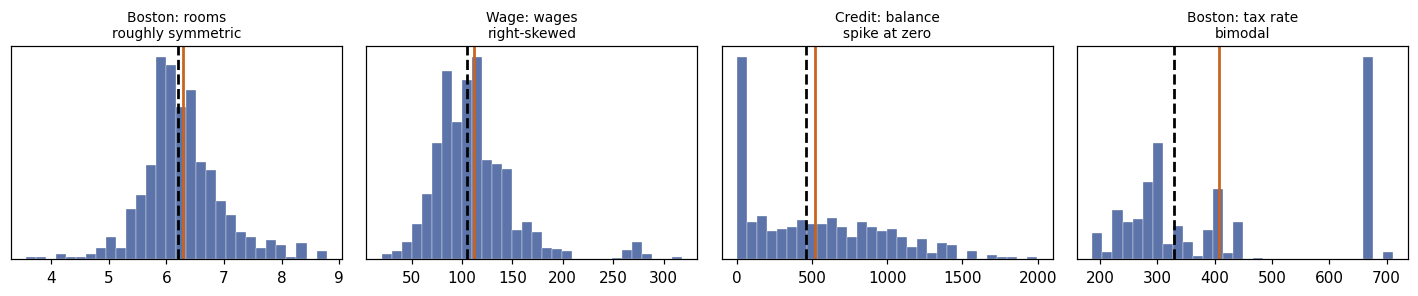

share of Credit customers with a zero balance: 0.225


In [9]:
# Four shapes, all from the course data (the deck's gallery).
Boston, Credit = load('Boston'), load('Credit')
panels = [(Boston['rm'],       'Boston: rooms',        'roughly symmetric'),
          (Wage['wage'],       'Wage: wages',          'right-skewed'),
          (Credit['Balance'],  'Credit: balance',      'spike at zero'),
          (Boston['tax'],      'Boston: tax rate',     'bimodal')]

fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, (v, title, shape) in zip(axes, panels):
    ax.hist(v, bins=30, color=ACCENT, alpha=.75, edgecolor='white', lw=.3)
    ax.axvline(v.mean(), color=ORANGE, lw=1.8)
    ax.axvline(v.median(), color='black', lw=1.8, ls='--')
    ax.set_title(f'{title}\n{shape}', fontsize=9); ax.set_yticks([])
plt.tight_layout(); plt.show()

print('share of Credit customers with a zero balance:', (Credit['Balance'] == 0).mean().round(3))

z-scores: mean 2.14e-16, sd 1.000
skewness: wage +1.68   log(wage) -0.12


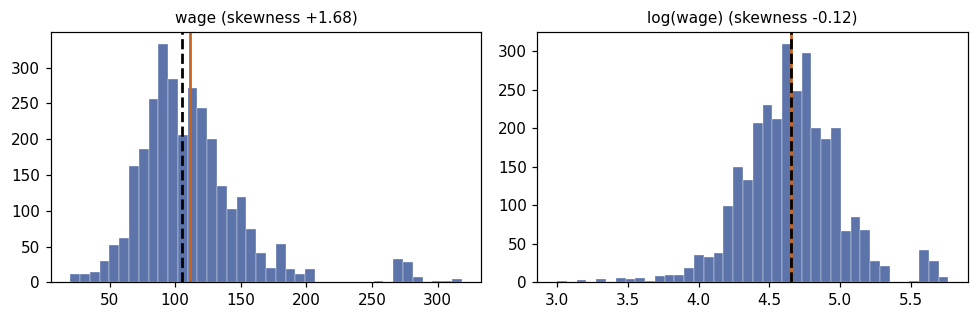

In [10]:
# Standardising, and what a log transform does to skew.
z = (w - w.mean()) / w.std(ddof=1)
print(f'z-scores: mean {z.mean():.2e}, sd {z.std(ddof=1):.3f}')
print(f'skewness: wage {stats.skew(w):+.2f}   log(wage) {stats.skew(np.log(w)):+.2f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, v, name in [(axes[0], w, 'wage'), (axes[1], np.log(w), 'log(wage)')]:
    ax.hist(v, bins=40, color=ACCENT, alpha=.75, edgecolor='white', lw=.3)
    ax.axvline(np.mean(v), color=ORANGE, lw=1.8)
    ax.axvline(np.median(v), color='black', lw=1.8, ls='--')
    ax.set_title(f'{name} (skewness {stats.skew(v):+.2f})', fontsize=10)
plt.tight_layout(); plt.show()

## 3. Describing two variables: covariance, correlation, and their traps

Covariance says whether two variables move together; dividing by both SDs makes it unit-free and gives $r \in [-1, 1]$.

In [11]:
adv = load('Advertising', index_col=0)
print(adv.head(3).to_string())

cov = np.cov(adv['TV'], adv['sales'], ddof=1)[0, 1]
r   = np.corrcoef(adv['TV'], adv['sales'])[0, 1]
print(f'\ncov(TV, sales) = {cov:.2f}   (units: $000 x thousands of units)')
print(f'r(TV, sales)   = {r:.3f}   (unit-free)')
print(f'\nsame r after changing units to single dollars: '
      f'{np.corrcoef(adv["TV"]*1000, adv["sales"]).round(3)[0,1]}')
adv.corr().round(3)

      TV  radio  newspaper  sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3

cov(TV, sales) = 350.39   (units: $000 x thousands of units)
r(TV, sales)   = 0.782   (unit-free)

same r after changing units to single dollars: 0.782


,TV,radio,newspaper,sales
TV,1.000,0.055,0.057,0.782
radio,0.055,1.000,0.354,0.576
newspaper,0.057,0.354,1.000,0.228
sales,0.782,0.576,0.228,1.000


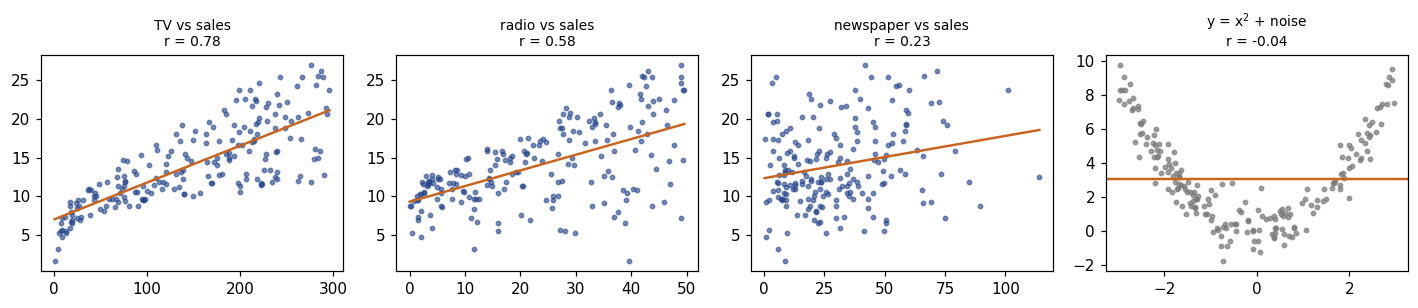

In [12]:
# What r sees -- and what it misses.
fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper']):
    ax.scatter(adv[col], adv['sales'], s=8, color=ACCENT, alpha=.6)
    b, a = np.polyfit(adv[col], adv['sales'], 1)
    xs = np.linspace(adv[col].min(), adv[col].max(), 50)
    ax.plot(xs, a + b*xs, color=ORANGE, lw=1.6)
    ax.set_title(f'{col} vs sales\nr = {adv[col].corr(adv["sales"]):.2f}', fontsize=9)

xq = rng.uniform(-3, 3, 200); yq = xq**2 + rng.normal(0, .8, 200)
axes[3].scatter(xq, yq, s=8, color=GREY, alpha=.7)
axes[3].axhline(yq.mean(), color=ORANGE, lw=1.6)
axes[3].set_title(f'y = x$^2$ + noise\nr = {np.corrcoef(xq, yq)[0,1]:.2f}', fontsize=9)
plt.tight_layout(); plt.show()

### Anscombe's quartet
Four data sets with the same means, SDs, correlation and fitted line — and four different stories.

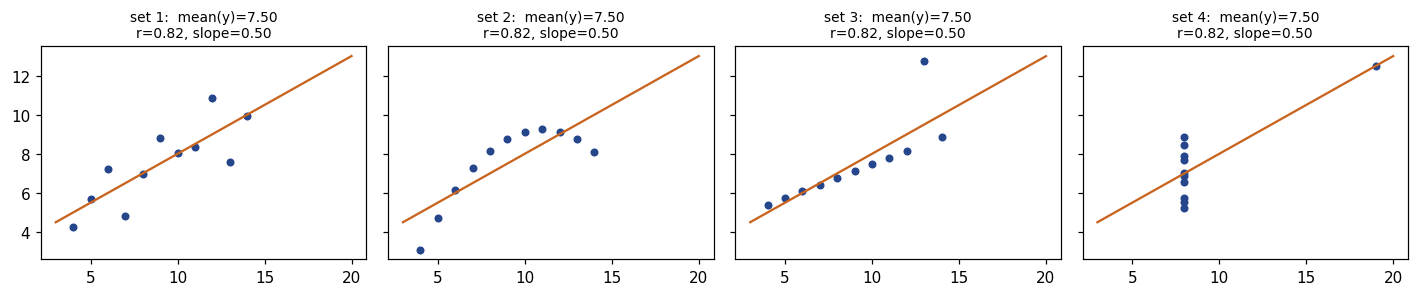

In [13]:
x1 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], float)
x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], float)
quartet = [
    (x1, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    (x1, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    (x1, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    (x4, [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])]

fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharex=True, sharey=True)
for k, (ax, (xa, ya)) in enumerate(zip(axes, quartet), start=1):
    ya = np.asarray(ya)
    b1, b0 = np.polyfit(xa, ya, 1)
    ax.scatter(xa, ya, s=18, color=ACCENT)
    xs = np.linspace(3, 20, 20); ax.plot(xs, b0 + b1*xs, color=ORANGE, lw=1.5)
    ax.set_title(f'set {k}:  mean(y)={ya.mean():.2f}\nr={np.corrcoef(xa, ya)[0,1]:.2f}, '
                 f'slope={b1:.2f}', fontsize=9)
plt.tight_layout(); plt.show()

### Simpson's paradox
An association can reverse once you condition on a group — which is exactly what adding a variable to a regression does.

In [14]:
rng_s = np.random.default_rng(7)
groups, frames = ['30s', '50s', '70s'], []
for g, bx, by in zip(groups, (2.0, 4.5, 7.0), (4.0, 6.0, 8.0)):
    xs = bx + rng_s.normal(0, .6, 40)
    ys = by - .5*(xs - bx) + rng_s.normal(0, .35, 40)
    frames.append(pd.DataFrame({'exercise': xs, 'cholesterol': ys, 'age_group': g}))
sim = pd.concat(frames, ignore_index=True)

overall = np.polyfit(sim.exercise, sim.cholesterol, 1)[0]
within  = sim.groupby('age_group').apply(
    lambda d: np.polyfit(d.exercise, d.cholesterol, 1)[0], include_groups=False)
print(f'slope ignoring age group : {overall:+.2f}')
print('slope within each group  :', within.round(2).to_dict())

slope ignoring age group : +0.66
slope within each group  : {'30s': -0.58, '50s': -0.47, '70s': -0.57}


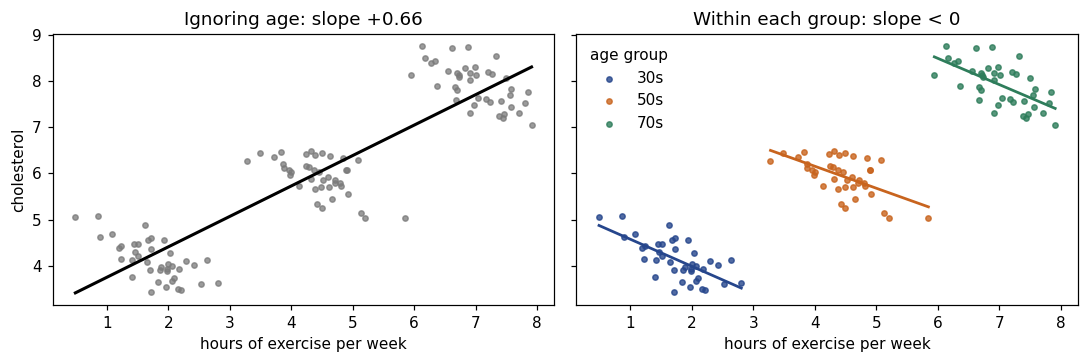

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
ax1.scatter(sim.exercise, sim.cholesterol, s=12, color=GREY, alpha=.75)
xs = np.linspace(sim.exercise.min(), sim.exercise.max(), 20)
b1, b0 = np.polyfit(sim.exercise, sim.cholesterol, 1)
ax1.plot(xs, b0 + b1*xs, color='black', lw=2)
ax1.set_title(f'Ignoring age: slope {b1:+.2f}')
for (g, d), c in zip(sim.groupby('age_group'), [ACCENT, ORANGE, '#2E7D5B']):
    ax2.scatter(d.exercise, d.cholesterol, s=12, color=c, alpha=.8, label=g)
    b1g, b0g = np.polyfit(d.exercise, d.cholesterol, 1)
    xg = np.linspace(d.exercise.min(), d.exercise.max(), 20)
    ax2.plot(xg, b0g + b1g*xg, color=c, lw=1.8)
ax2.legend(title='age group', frameon=False); ax2.set_title('Within each group: slope < 0')
for ax in (ax1, ax2): ax.set_xlabel('hours of exercise per week')
ax1.set_ylabel('cholesterol'); plt.tight_layout(); plt.show()

### Two categorical variables: the contingency table

In [16]:
tab = pd.DataFrame({'bought': [45, 25], 'did_not': [55, 75]},
                   index=['promotion', 'no promotion'])
display(tab)
print('\nrow proportions (what you compare):')
display(tab.div(tab.sum(axis=1), axis=0).round(3))

chi2, pval, dof, expected = stats.chi2_contingency(tab)
print(f'expected counts under independence:\n{np.round(expected, 1)}')
print(f'\nchi2 = {chi2:.2f}, df = {dof}, p = {pval:.4f}')

,bought,did_not
promotion,45,55
no promotion,25,75



row proportions (what you compare):


,bought,did_not
promotion,0.45,0.55
no promotion,0.25,0.75


expected counts under independence:
[[35. 65.]
 [35. 65.]]

chi2 = 7.93, df = 1, p = 0.0049


## 4. Probability, Bayes and the rules of expectation

The single most useful probability fact in this course: a test's accuracy tells you $P(+\mid\text{ill})$, but you want $P(\text{ill}\mid+)$ — and converting between them depends on the **base rate**.

In [17]:
def posterior(prevalence, sensitivity, specificity):
    tp = sensitivity * prevalence
    fp = (1 - specificity) * (1 - prevalence)
    return tp / (tp + fp)

print(f'P(ill | +) = {posterior(0.01, 0.90, 0.95):.3f}')      # the deck's example

# The same thing as natural frequencies, per 1000 people:
n = 1000
ill, healthy = 0.01*n, 0.99*n
tp, fp = 0.90*ill, 0.05*healthy
print(f'\nof {n} people: {ill:.0f} ill -> {tp:.0f} test positive')
print(f'              {healthy:.0f} healthy -> {fp:.0f} test positive')
print(f'{tp+fp:.0f} positives in total, {tp:.0f} of them ill  ->  {tp/(tp+fp):.1%}')

P(ill | +) = 0.154

of 1000 people: 10 ill -> 9 test positive
              990 healthy -> 50 test positive
58 positives in total, 9 of them ill  ->  15.4%


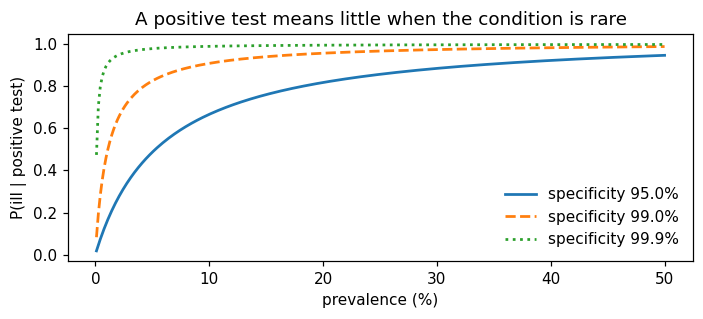

In [18]:
# How the answer depends on the base rate -- the whole story in one plot.
prev = np.linspace(0.001, 0.5, 300)
fig, ax = plt.subplots(figsize=(6.5, 3))
for spec, ls in [(0.95, '-'), (0.99, '--'), (0.999, ':')]:
    ax.plot(prev*100, [posterior(p, 0.90, spec) for p in prev], ls=ls, lw=1.8,
            label=f'specificity {spec:.1%}')
ax.set_xlabel('prevalence (%)'); ax.set_ylabel('P(ill | positive test)')
ax.set_title('A positive test means little when the condition is rare')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [19]:
# Expectation and variance rules, checked by simulation (Exercise 0.5).
draws = rng.normal(500, 4, 200_000)                 # E[X]=500, Var(X)=16
print(f'Var(X)      {draws.var(ddof=1):8.3f}   (theory 16)')
print(f'Var(X + 3)  {(draws + 3).var(ddof=1):8.3f}   (theory 16 -- shifting does not change spread)')
print(f'Var(X/1000) {(draws/1000).var(ddof=1):.3e}   (theory 1.6e-05 -- scaling squares)')

crates = rng.normal(500, 4, (100_000, 4))           # 4 independent bottles
print(f'\nVar(total of 4)   {crates.sum(axis=1).var(ddof=1):7.2f}   (theory 64)')
print(f'SD(mean of 4)     {crates.mean(axis=1).std(ddof=1):7.3f}   (theory 4/sqrt(4) = 2)')

Var(X)        15.997   (theory 16)
Var(X + 3)    15.997   (theory 16 -- shifting does not change spread)
Var(X/1000) 1.600e-05   (theory 1.6e-05 -- scaling squares)

Var(total of 4)     64.55   (theory 64)
SD(mean of 4)       2.009   (theory 4/sqrt(4) = 2)


## 5. The distributions you will meet

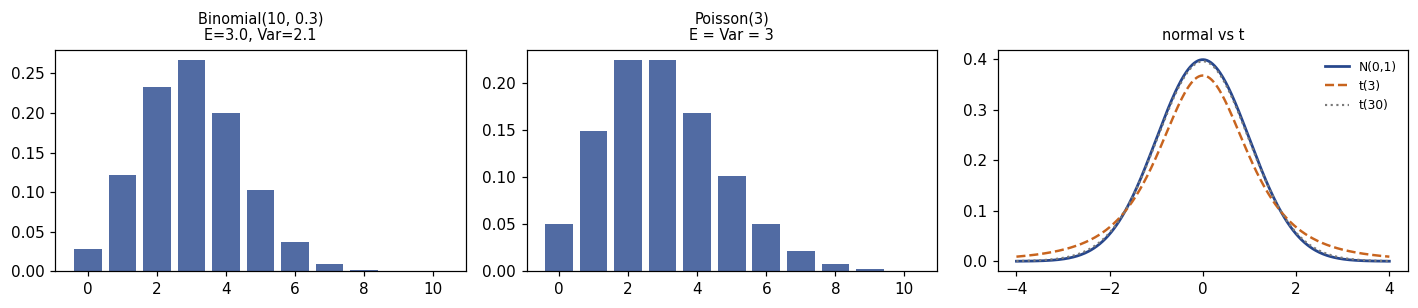

P(|Z| < 1)   = 0.6827
P(|Z| < 1.96)= 0.95
P(|Z| < 3)   = 0.9973
t quantiles (0.975): [2.571, 2.042, 1.984, 1.96]


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 2.9))
k = np.arange(0, 11)
axes[0].bar(k, stats.binom.pmf(k, 10, 0.3), color=ACCENT, alpha=.8)
axes[0].set_title('Binomial(10, 0.3)\nE=3.0, Var=2.1', fontsize=9.5)
axes[1].bar(k, stats.poisson.pmf(k, 3), color=ACCENT, alpha=.8)
axes[1].set_title('Poisson(3)\nE = Var = 3', fontsize=9.5)
z = np.linspace(-4, 4, 400)
axes[2].plot(z, stats.norm.pdf(z), color=ACCENT, lw=1.8, label='N(0,1)')
axes[2].plot(z, stats.t.pdf(z, 3), color=ORANGE, lw=1.6, ls='--', label='t(3)')
axes[2].plot(z, stats.t.pdf(z, 30), color=GREY, lw=1.4, ls=':', label='t(30)')
axes[2].legend(frameon=False, fontsize=8); axes[2].set_title('normal vs t', fontsize=9.5)
plt.tight_layout(); plt.show()

print('P(|Z| < 1)   =', round(stats.norm.cdf(1) - stats.norm.cdf(-1), 4))
print('P(|Z| < 1.96)=', round(stats.norm.cdf(1.96) - stats.norm.cdf(-1.96), 4))
print('P(|Z| < 3)   =', round(stats.norm.cdf(3) - stats.norm.cdf(-3), 4))
print('t quantiles (0.975):', [round(float(stats.t.ppf(.975, df)), 3) for df in (5, 30, 100, 10000)])

The 68–95–99.7 rule, and $t_\nu \to N(0,1)$ as the degrees of freedom grow: with $\nu > 30$ the difference is negligible, which is why $1.96$ is worth memorising.

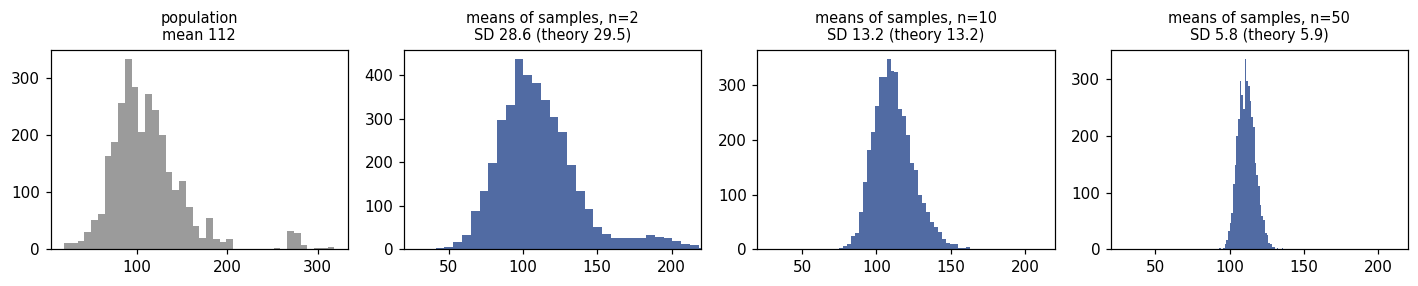

In [21]:
# The central limit theorem, using the (very skewed) wage distribution.
pop = Wage['wage'].to_numpy()
fig, axes = plt.subplots(1, 4, figsize=(13, 2.7))
axes[0].hist(pop, bins=40, color=GREY, alpha=.75)
axes[0].set_title(f'population\nmean {pop.mean():.0f}', fontsize=9.5)
for ax, n in zip(axes[1:], (2, 10, 50)):
    means = rng.choice(pop, size=(4000, n)).mean(axis=1)
    ax.hist(means, bins=40, color=ACCENT, alpha=.8)
    ax.set_title(f'means of samples, n={n}\nSD {means.std(ddof=1):.1f} '
                 f'(theory {pop.std(ddof=1)/np.sqrt(n):.1f})', fontsize=9.5)
    ax.set_xlim(20, 220)
plt.tight_layout(); plt.show()

## 6. Standard errors and confidence intervals

The **standard deviation** describes the data; the **standard error** describes an *estimate*, and only the latter shrinks with $n$.

In [22]:
for n in (100, 400, 1600):
    s = pop.std(ddof=1)
    print(f'n = {n:5d}:  SD of the data = {s:6.2f}   SE of the mean = {s/np.sqrt(n):5.2f}')

n =   100:  SD of the data =  41.73   SE of the mean =  4.17
n =   400:  SD of the data =  41.73   SE of the mean =  2.09
n =  1600:  SD of the data =  41.73   SE of the mean =  1.04


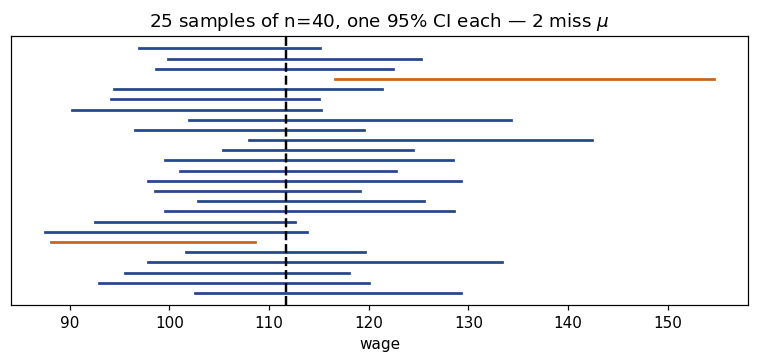

coverage over 5000 repetitions: 0.930


In [23]:
# What "95% confident" actually means: repeat the whole procedure many times.
def one_interval(n, rng_):
    s = rng_.choice(pop, size=n)
    half = stats.t.ppf(.975, n-1) * s.std(ddof=1) / np.sqrt(n)
    return s.mean() - half, s.mean() + half

mu = pop.mean()
rng_ci = np.random.default_rng(3)
intervals = [one_interval(40, rng_ci) for _ in range(25)]
misses = sum(not (lo <= mu <= hi) for lo, hi in intervals)

fig, ax = plt.subplots(figsize=(7, 3.4))
for i, (lo, hi) in enumerate(intervals):
    covers = lo <= mu <= hi
    ax.plot([lo, hi], [i, i], color=ACCENT if covers else ORANGE, lw=1.8)
ax.axvline(mu, color='black', ls='--', lw=1.6)
ax.set_yticks([]); ax.set_xlabel('wage')
ax.set_title(f'25 samples of n=40, one 95% CI each — {misses} miss $\\mu$')
plt.tight_layout(); plt.show()

# ... and the long-run coverage, over 5000 repetitions:
cover = np.mean([lo <= mu <= hi for lo, hi in (one_interval(40, rng_ci) for _ in range(5000))])
print(f'coverage over 5000 repetitions: {cover:.3f}')

## 7. Hypothesis tests, $p$-values and power

In [24]:
# The deck's one-sample t-test, by hand and with scipy.
xbar, s, n, mu0 = 103, 15, 100, 100
se = s / np.sqrt(n)
t_stat = (xbar - mu0) / se
p_val = 2 * stats.t.sf(abs(t_stat), n - 1)
half = stats.t.ppf(.975, n - 1) * se
print(f'SE = {se:.2f}   t = {t_stat:.2f}   p = {p_val:.4f}')
print(f'95% CI = [{xbar - half:.2f}, {xbar + half:.2f}]  -> excludes 100, so the test rejects')

SE = 1.50   t = 2.00   p = 0.0482
95% CI = [100.02, 105.98]  -> excludes 100, so the test rejects


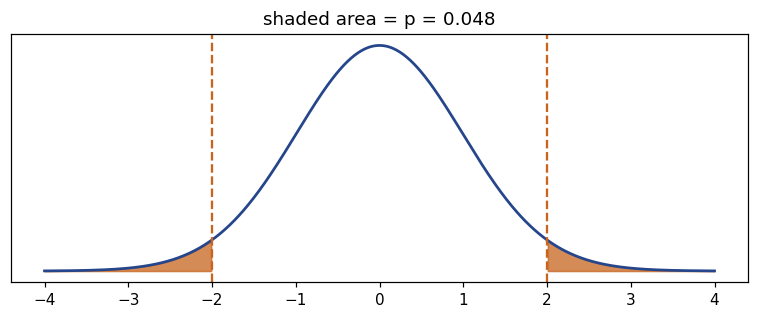

In [25]:
# A p-value is an area under the null distribution.
tt = np.linspace(-4, 4, 600); dens = stats.t.pdf(tt, 99)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tt, dens, color=ACCENT, lw=1.8)
for side in (1, -1):
    m = tt*side >= t_stat
    ax.fill_between(tt[m], dens[m], color=ORANGE, alpha=.75)
ax.axvline(t_stat, color=ORANGE, ls='--'); ax.axvline(-t_stat, color=ORANGE, ls='--')
ax.set_yticks([]); ax.set_title(f'shaded area = p = {p_val:.3f}')
plt.tight_layout(); plt.show()

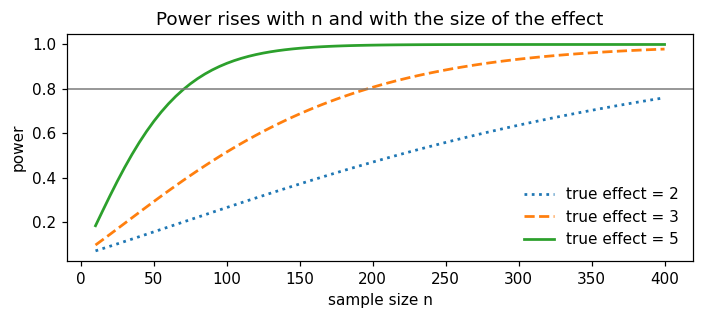

n needed for 80% power at effect = 3: 200


In [26]:
# Power: the probability of detecting an effect that is really there.
def power(n, effect, sd=15, alpha=.05):
    se_ = sd / np.sqrt(n)
    crit = stats.norm.ppf(1 - alpha/2) * se_
    return stats.norm.sf(crit, loc=effect, scale=se_) + stats.norm.cdf(-crit, loc=effect, scale=se_)

ns = np.arange(10, 401, 5)
fig, ax = plt.subplots(figsize=(6.5, 3))
for eff, ls in [(2, ':'), (3, '--'), (5, '-')]:
    ax.plot(ns, [power(n_, eff) for n_ in ns], ls=ls, lw=1.8, label=f'true effect = {eff}')
ax.axhline(.8, color=GREY, lw=1)
ax.set_xlabel('sample size n'); ax.set_ylabel('power'); ax.legend(frameon=False)
ax.set_title('Power rises with n and with the size of the effect')
plt.tight_layout(); plt.show()

print('n needed for 80% power at effect = 3:', next(n_ for n_ in ns if power(n_, 3) >= .8))

**Multiple testing, in two lines.** Test 40 true nulls at the 5% level and you expect 2 false positives — this is the entire motivation for Chapter 13.

In [27]:
sig = [(rng.normal(0, 1, 30).mean() / (1/np.sqrt(30))) for _ in range(40)]
pvals = [2*stats.norm.sf(abs(t_)) for t_ in sig]
print('significant at 5% among 40 true nulls:', sum(p < .05 for p in pvals))
print('P(at least one) = 1 - 0.95**40 =', round(1 - .95**40, 3))

significant at 5% among 40 true nulls: 2
P(at least one) = 1 - 0.95**40 = 0.871


## 8. Simple linear regression — the bridge into Chapter 3

In [28]:
# By hand, exactly as on the slides (Extended Exercise 0.2).
X4 = np.array([2., 4., 6., 8.]); Y4 = np.array([5., 8., 12., 15.])
Sxx = ((X4 - X4.mean())**2).sum()
Sxy = ((X4 - X4.mean())*(Y4 - Y4.mean())).sum()
b1 = Sxy / Sxx; b0 = Y4.mean() - b1*X4.mean()
fitted = b0 + b1*X4; resid = Y4 - fitted
rss = (resid**2).sum(); tss = ((Y4 - Y4.mean())**2).sum()
print(f'b1 = {b1:.2f}, b0 = {b0:.2f}   ->  y_hat = {b0:.1f} + {b1:.1f} x')
print(f'residuals {np.round(resid, 3)}  (they sum to {resid.sum():.1e})')
print(f'RSS = {rss:.2f}, TSS = {tss:.0f}, R2 = {1 - rss/tss:.5f}  '
      f'(= r^2 = {np.corrcoef(X4, Y4)[0,1]**2:.5f})')

b1 = 1.70, b0 = 1.50   ->  y_hat = 1.5 + 1.7 x
residuals [ 0.1 -0.3  0.3 -0.1]  (they sum to 0.0e+00)
RSS = 0.20, TSS = 58, R2 = 0.99655  (= r^2 = 0.99655)


In [29]:
# The same model on real data, with statsmodels -- the table of Chapter 3.
fit = smf.ols('sales ~ TV', data=adv).fit()
print(fit.summary().tables[1])
print(f'R-squared = {fit.rsquared:.3f}')
print('\nt = coef / std err =', round(fit.params['TV'] / fit.bse['TV'], 2))
print('95% CI:', fit.conf_int().loc['TV'].round(4).tolist())

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.0326      0.458     15.360      0.000       6.130       7.935
TV             0.0475      0.003     17.668      0.000       0.042       0.053
R-squared = 0.612

t = coef / std err = 17.67
95% CI: [0.0422, 0.0528]


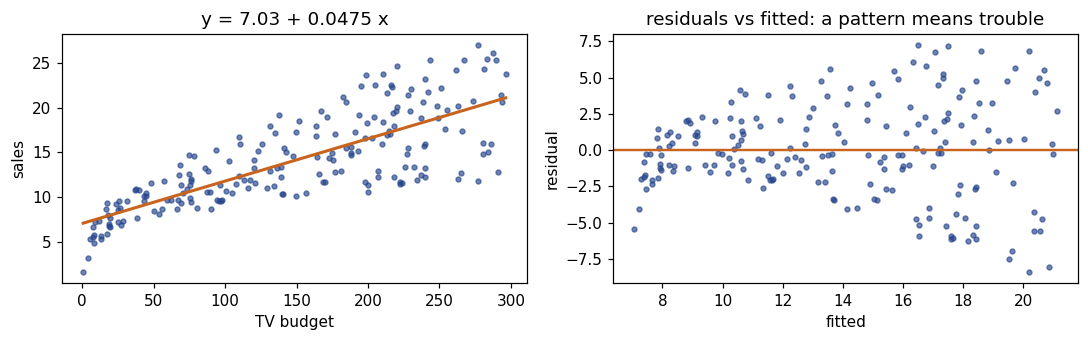

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.scatter(adv.TV, adv.sales, s=10, color=ACCENT, alpha=.65)
xs = np.linspace(adv.TV.min(), adv.TV.max(), 50)
ax1.plot(xs, fit.params['Intercept'] + fit.params['TV']*xs, color=ORANGE, lw=2)
ax1.set_xlabel('TV budget'); ax1.set_ylabel('sales')
ax1.set_title(f'y = {fit.params["Intercept"]:.2f} + {fit.params["TV"]:.4f} x')
ax2.scatter(fit.fittedvalues, fit.resid, s=10, color=ACCENT, alpha=.65)
ax2.axhline(0, color=ORANGE, lw=1.6)
ax2.set_xlabel('fitted'); ax2.set_ylabel('residual')
ax2.set_title('residuals vs fitted: a pattern means trouble')
plt.tight_layout(); plt.show()

### One point can move the whole line
An **outlier** has a large residual; a **high-leverage** point has an unusual $x$. The second is far more dangerous.

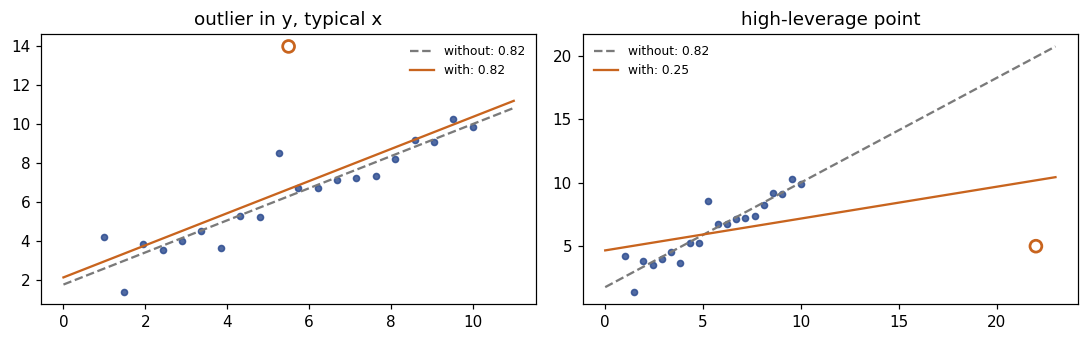

In [31]:
rng_o = np.random.default_rng(3)
xo = np.linspace(1, 10, 20); yo = 2 + .8*xo + rng_o.normal(0, .7, 20)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (px, py, title) in zip(axes, [(5.5, 14.0, 'outlier in y, typical x'),
                                      (22.0, 5.0, 'high-leverage point')]):
    xa, ya = np.append(xo, px), np.append(yo, py)
    s_before = np.polyfit(xo, yo, 1)[0]; s_after = np.polyfit(xa, ya, 1)[0]
    grid = np.linspace(0, max(11, px+1), 50)
    ax.scatter(xo, yo, s=16, color=ACCENT, alpha=.8)
    ax.scatter([px], [py], s=60, facecolors='none', edgecolors=ORANGE, lw=1.8)
    ax.plot(grid, np.polyval(np.polyfit(xo, yo, 1), grid), color=GREY, ls='--',
            label=f'without: {s_before:.2f}')
    ax.plot(grid, np.polyval(np.polyfit(xa, ya, 1), grid), color=ORANGE,
            label=f'with: {s_after:.2f}')
    ax.set_title(title); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 9. The linear algebra you will need

$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ — and why the inverse sometimes does not exist.

In [32]:
Xm = np.array([[1., 1.], [1., 2.], [1., 3.]])     # first column = intercept
y3 = np.array([2., 3., 5.])
print('X.T @ X =\n', Xm.T @ Xm, '\n\nX.T @ y =', Xm.T @ y3)
print('\nbeta_hat =', np.linalg.solve(Xm.T @ Xm, Xm.T @ y3).round(4))   # (1/3, 3/2)
print('same via lstsq:', np.linalg.lstsq(Xm, y3, rcond=None)[0].round(4))

X.T @ X =
 [[ 3.  6.]
 [ 6. 14.]] 

X.T @ y = [10. 23.]

beta_hat = [0.3333 1.5   ]
same via lstsq: [0.3333 1.5   ]


In [33]:
# Perfect collinearity: add a column that is twice another one.
Xbad = np.column_stack([Xm, 2*Xm[:, 1]])
print('det(X.T X) =', round(float(np.linalg.det(Xbad.T @ Xbad)), 12))
try:
    np.linalg.inv(Xbad.T @ Xbad)
except np.linalg.LinAlgError as e:
    print('inversion failed:', e)
print('\nridge fixes it by inverting (X.T X + lambda I):')
print(np.linalg.inv(Xbad.T @ Xbad + 0.1*np.eye(3)).round(3))

det(X.T X) = 0.0
inversion failed: Singular matrix

ridge fixes it by inverting (X.T X + lambda I):
[[ 1.879 -0.161 -0.322]
 [-0.161  8.017 -3.967]
 [-0.322 -3.967  2.066]]


In [34]:
# Norms, distances and eigenvectors -- the ideas behind Ch 6 and Ch 12.
beta = np.array([3., -4., 0.5])
print(f'L2 norm  {np.linalg.norm(beta, 2):.3f}   (ridge penalises this, squared)')
print(f'L1 norm  {np.linalg.norm(beta, 1):.3f}   (lasso penalises this -> exact zeros)')

C = np.cov(Boston[['rm', 'lstat', 'medv']].to_numpy().T)
vals, vecs = np.linalg.eigh(C)
print('\neigenvalues of the covariance matrix:', np.round(vals[::-1], 2))
print('share of variance in the first component:', round(vals[::-1][0]/vals.sum(), 3))

L2 norm  5.025   (ridge penalises this, squared)
L1 norm  7.500   (lasso penalises this -> exact zeros)

eigenvalues of the covariance matrix: [119.32  16.51   0.24]
share of variance in the first component: 0.877


## 10. Calculus and gradient descent

Every method in this course minimises a loss: differentiate, set to zero and solve — or walk downhill when no closed form exists.

In [35]:
def loss(b, X=Xm, y=y3):      return float(((y - X @ b)**2).sum())
def grad(b, X=Xm, y=y3):      return -2 * X.T @ (y - X @ b)

beta_hat = np.linalg.solve(Xm.T @ Xm, Xm.T @ y3)
b = np.zeros(2)
print(f'start: beta = {b}, L = {loss(b):.2f}, gradient = {grad(b)}')
b = b - 0.01*grad(b)
print(f'after one step (alpha=0.01): beta = {b.round(3)}, L = {loss(b):.2f}')
print(f'optimum: beta = {beta_hat.round(3)}, L = {loss(beta_hat):.4f}')

start: beta = [0. 0.], L = 38.00, gradient = [-20. -46.]
after one step (alpha=0.01): beta = [0.2  0.46], L = 17.03
optimum: beta = [0.333 1.5  ], L = 0.1667


In [36]:
def descend(alpha, steps):
    b_, path = np.zeros(2), [np.zeros(2)]
    for _ in range(steps):
        b_ = b_ - alpha*grad(b_); path.append(b_.copy())
    return np.array(path)

for alpha in (0.001, 0.01, 0.05, 0.07):
    p_ = descend(alpha, 60)
    end = loss(p_[-1])
    print(f'alpha = {alpha:<6}  loss after 60 steps = '
          f'{end:12.4f}  {"DIVERGED" if end > 38 else ""}')
print('\nthe stability limit is 2 / largest eigenvalue of 2 X.T X =',
      round(2/np.linalg.eigvalsh(2*Xm.T @ Xm).max(), 4))

alpha = 0.001   loss after 60 steps =       0.8473  
alpha = 0.01    loss after 60 steps =       0.1802  
alpha = 0.05    loss after 60 steps =       0.1671  
alpha = 0.07    loss after 60 steps = 26350532281728104.0000  DIVERGED

the stability limit is 2 / largest eigenvalue of 2 X.T X = 0.0601


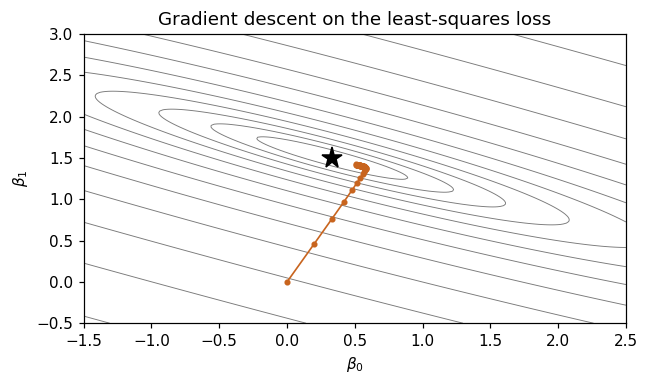

In [37]:
g0, g1 = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-.5, 3, 200))
Z = np.array([[loss(np.array([a, b_])) for a in g0[0]] for b_ in g1[:, 0]])

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.contour(g0, g1, Z, levels=np.geomspace(.3, 300, 14), colors=[GREY], linewidths=.6)
p_ = descend(0.01, 60)
ax.plot(p_[:, 0], p_[:, 1], '-o', color=ORANGE, ms=3, lw=1.1)
ax.plot(*beta_hat, '*', color='black', ms=14)
ax.set_xlabel(r'$\beta_0$'); ax.set_ylabel(r'$\beta_1$')
ax.set_title('Gradient descent on the least-squares loss')
plt.tight_layout(); plt.show()

## Lecture exercises — worked Python solutions

The Chapter 0 deck has two `[Python]`-tagged exercises. Both are solved here in full; the expected values from the slide solutions appear as trailing comments so you can check every step.

### Exercise 0.7 — Interrogating a regression table *(slide: Exercise 0.7 [Python])*

A colleague regresses monthly ice-cream sales (€000s) on average temperature (°C) and reports `coef 0.9000`, `std err 0.1500`, `t 6.00`, `[0.595, 1.205]`, `R² 0.51`, `n = 36`.

In [38]:
# Exercise 0.7 -- worked solution ---------------------------------------------
coef, se_coef, n_obs = 0.9, 0.15, 36

# (2) verify the t-value and the interval
t_reported = coef / se_coef
print(f'(2) t = coef/se = {t_reported:.2f}')                      # 6.00
rule_of_thumb = (coef - 1.96*se_coef, coef + 1.96*se_coef)
exact = stats.t.interval(0.95, n_obs - 2, loc=coef, scale=se_coef)
print(f'    +-1.96 SE : [{rule_of_thumb[0]:.3f}, {rule_of_thumb[1]:.3f}]')
print(f'    exact t   : [{exact[0]:.3f}, {exact[1]:.3f}]  <- matches the printout')
print(f'    t quantile at df={n_obs-2}: {stats.t.ppf(.975, n_obs-2):.3f} (vs 1.96)')

# (1),(3),(4): interpretation -- a 1 degree warmer MONTH is associated with
# EUR 900 more sales; the intercept is sales at 0 C, an extrapolation unless
# the city really gets that cold; R^2 = 0.55 means 45% of the variation is
# still unexplained -- and says nothing about causation.
print(f'\n(4) unexplained share of variation: {1 - 0.51:.0%}')

(2) t = coef/se = 6.00
    +-1.96 SE : [0.606, 1.194]
    exact t   : [0.595, 1.205]  <- matches the printout
    t quantile at df=34: 2.032 (vs 1.96)

(4) unexplained share of variation: 49%


**(5)** The causal wording fails twice: the data are observational (month, tourism, holidays and marketing all move with temperature — a confounder), and the coefficient is *per 1 °C of monthly average*, not per warm afternoon. Defensible version: *“months that are 1 °C warmer sell about €900 more, on average.”*

### Exercise 0.9 — Reading Python output *(slide: Exercise 0.9 [Python])*

The exercise quotes `df.shape`, `df["wage"].describe()` and `df["age"].corr(df["wage"])` for the `Wage` data. Here everything is recomputed from the real data.

In [39]:
# Exercise 0.9 -- worked solution ---------------------------------------------
d = Wage['wage'].describe()
print('(1) n =', Wage.shape[0], ' p =', Wage.shape[1])            # 3000, 11

iqr_w = d['75%'] - d['25%']
fence = d['75%'] + 1.5*iqr_w
print(f'(2) IQR = {iqr_w:.2f}, upper fence = {fence:.2f} '
      f'-> a wage of 220 is {"flagged" if 220 > fence else "not flagged"}')
print(f'    but {(Wage["wage"] > fence).sum()} of {len(Wage)} wages are beyond it '
      f'({(Wage["wage"] > fence).mean():.1%}) -- flagged means "look", not "delete"')

print(f'(3) mean {d["mean"]:.2f} > median {d["50%"]:.2f} -> right-skewed; '
      f'report the median and IQR too')
print(f'(4) r(age, wage) = {Wage["age"].corr(Wage["wage"]):.4f} -- weak LINEAR association only')
print(f'(5) SE of the mean wage = {d["std"]/np.sqrt(d["count"]):.3f}')

(1) n = 3000  p = 11
(2) IQR = 43.30, upper fence = 193.63 -> a wage of 220 is flagged
    but 109 of 3000 wages are beyond it (3.6%) -- flagged means "look", not "delete"
(3) mean 111.70 > median 104.92 -> right-skewed; report the median and IQR too
(4) r(age, wage) = 0.1956 -- weak LINEAR association only
(5) SE of the mean wage = 0.762


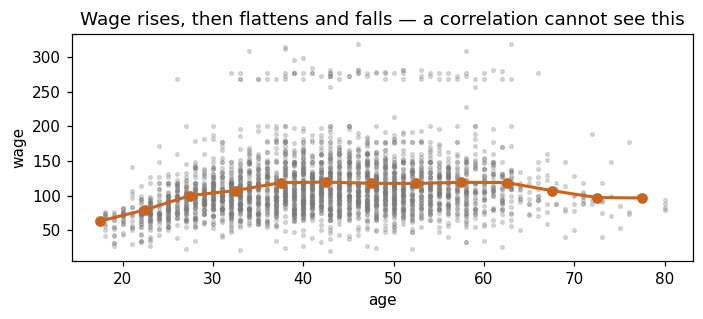

In [40]:
# (4) continued: r is small because the relationship is CURVED, not because
# age is unimportant. Binned means show the shape that Chapter 7 will model.
bins = pd.cut(Wage['age'], bins=np.arange(15, 85, 5))
profile = Wage.groupby(bins, observed=True)['wage'].mean()

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.scatter(Wage['age'], Wage['wage'], s=6, color=GREY, alpha=.25)
ax.plot([iv.mid for iv in profile.index], profile.values, '-o', color=ORANGE, lw=2)
ax.set_xlabel('age'); ax.set_ylabel('wage')
ax.set_title('Wage rises, then flattens and falls — a correlation cannot see this')
plt.tight_layout(); plt.show()

### Checking the hand-computed exercises

The `[Math]` exercises of the deck are quick to verify numerically — a good habit for your own problem sets.

In [41]:
# Exercise 0.2 -- service times
svc = np.array([3, 5, 6, 6, 8, 9, 21])
print(f'0.2  mean {svc.mean():.4f}  median {np.median(svc)}  '
      f's2 {svc.var(ddof=1):.3f}  s {svc.std(ddof=1):.3f}')
print(f'     after fixing the typo 21 -> 12: mean '
      f'{np.array([3,5,6,6,8,9,12]).mean():.3f}, median {np.median([3,5,6,6,8,9,12])}')

# Exercise 0.3 -- five stores
xs5 = np.array([1, 2, 3, 4, 5]); ys5 = np.array([2, 4, 5, 4, 10])
Sxx5 = ((xs5-3)**2).sum(); Syy5 = ((ys5-5)**2).sum(); Sxy5 = ((xs5-3)*(ys5-5)).sum()
print(f'0.3  Sxx {Sxx5}  Syy {Syy5}  Sxy {Sxy5}  '
      f'r {Sxy5/np.sqrt(Sxx5*Syy5):.4f}  b1 {Sxy5/Sxx5:.2f}')

# Exercise 0.4 -- the fraud filter
pf, pl = .95*.005, .02*.995
print(f'0.4  P(flag) {pf+pl:.5f}   P(fraud | flag) {pf/(pf+pl):.4f}')

# Extended Exercise 0.1 -- basket values
se_b = 12/np.sqrt(64); t_b = (48.5-45)/se_b
print(f'E0.1 SE {se_b}  t {t_b:.2f}  p {2*stats.t.sf(t_b, 63):.4f}  '
      f'n for half-width 1.0: {np.ceil((1.96*12)**2):.0f}')

0.2  mean 8.2857  median 6.0  s2 35.238  s 5.936
     after fixing the typo 21 -> 12: mean 7.000, median 6.0
0.3  Sxx 10  Syy 36  Sxy 16  r 0.8433  b1 1.60
0.4  P(flag) 0.02465   P(fraud | flag) 0.1927
E0.1 SE 1.5  t 2.33  p 0.0228  n for half-width 1.0: 554


## Exercises

Work these before Lecture 1. They use only what is above.

1. **Describe a variable.** Pick `Boston['medv']`. Report mean, median, SD, IQR, and the number of points flagged by the $1.5\times$IQR rule. Is the mean or the median the better summary here, and why? Plot a histogram and a boxplot side by side.
2. **Correlation, carefully.** Compute the correlation matrix of `Boston[['rm','lstat','medv']]`. Which pair is strongest? Plot that pair — is a straight line a fair description? Now compute the correlation after squaring `lstat` and comment.
3. **Base rates.** A screening test has sensitivity 99% and specificity 99%. Plot $P(\text{ill}\mid+)$ against a prevalence running from 0.01% to 5%. At what prevalence does a positive test finally mean "more likely ill than not"?
4. **Standard errors.** Draw 1000 samples of size 25 from `Wage['wage']` and one of size 400. Compare the SD of the sample means with $\sigma/\sqrt n$ in both cases.
5. **A test and an interval.** Test whether the mean `wage` of workers with a college degree or more differs from that of the rest. Report the difference, its 95% CI, and the $p$-value — and say which of the three you would put in a slide first.
6. **Regression.** Fit `sales ~ radio` on `Advertising`. Interpret the slope with units, give its CI, and plot residuals against fitted values. Compare $R^2$ with the `TV` model above.
7. **Leverage.** Take the `TV` model, append one artificial observation at `TV = 900, sales = 5`, and refit. How much does the slope move? Explain in one sentence.
8. **Gradient descent.** Standardise `TV` before fitting `sales ~ TV` by gradient descent. Does the largest usable learning rate change? Why?

## Where to go next

- **Slides:** `Lecture_Slides/chapter_00/chapter_00.pdf` — every topic above, with worked solutions to all ten short and four extended exercises.
- **Next lab:** `chapter_01_lab.ipynb` — the course proper begins: what statistical learning is, and the three motivating data sets.